# 01 Data Exploration

Explore the image deepfake dataset in `data/splits/images`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, UnidentifiedImageError

DATA_ROOT = Path("../../data/raw/images")
SPLITS = ["train", "val", "test"]
CLASSES = ["real", "fake"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Dataset root exists: {DATA_ROOT.exists()}")

Dataset root: D:\Projects\Machine_Learning Projects\Cognito_AI_A.M\data\splits\images
Dataset root exists: True


In [2]:
def collect_image_paths(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for class_name in CLASSES:
            class_dir = data_root / split / class_name
            print(f"Scanning {class_dir} | exists={class_dir.exists()}")
            if not class_dir.exists():
                continue

            for path in sorted(class_dir.iterdir()):
                if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append(
                        {
                            "path": str(path),
                            "split": split,
                            "label": class_name,
                            "label_id": 1 if class_name == "fake" else 0,
                            "filename": path.name,
                        }
                    )
    return pd.DataFrame(rows)


df = collect_image_paths(DATA_ROOT)
print(f"Total image files found: {len(df)}")
df.head()

Scanning ..\data\splits\images\train\real | exists=True
Scanning ..\data\splits\images\train\fake | exists=True
Scanning ..\data\splits\images\val\real | exists=True
Scanning ..\data\splits\images\val\fake | exists=True
Scanning ..\data\splits\images\test\real | exists=True
Scanning ..\data\splits\images\test\fake | exists=True
Total image files found: 57098


,path,split,label,label_id,filename
0,..\data\splits\images\train\real\real_100.jpg,train,real,0,real_100.jpg
1,..\data\splits\images\train\real\real_10001.jpg,train,real,0,real_10001.jpg
2,..\data\splits\images\train\real\real_10002.jpg,train,real,0,real_10002.jpg
3,..\data\splits\images\train\real\real_10006.jpg,train,real,0,real_10006.jpg
4,..\data\splits\images\train\real\real_10013.jpg,train,real,0,real_10013.jpg


In [3]:
print("Class distribution by split:")
display(df.groupby(["split", "label"]).size().unstack(fill_value=0))

print("Overall class distribution:")
display(df["label"].value_counts())

Class distribution by split:


label,fake,real
split,,
test,1647,1623
train,21000,21000
val,5892,5936


Overall class distribution:


label
real    28559
fake    28539
Name: count, dtype: int64

In [4]:
def verify_paths_exist(paths: pd.Series) -> bool:
    missing = [path for path in paths if not Path(path).exists()]
    print(f"Checked paths: {len(paths)}")
    print(f"Missing paths: {len(missing)}")
    if missing:
        print("First missing paths:")
        for path in missing[:10]:
            print(path)
    return not missing


all_paths_exist = verify_paths_exist(df["path"])
print(f"All file paths exist: {all_paths_exist}")

Checked paths: 57098
Missing paths: 0
All file paths exist: True


Displaying 4 samples for train/real
Displaying 4 samples for train/fake


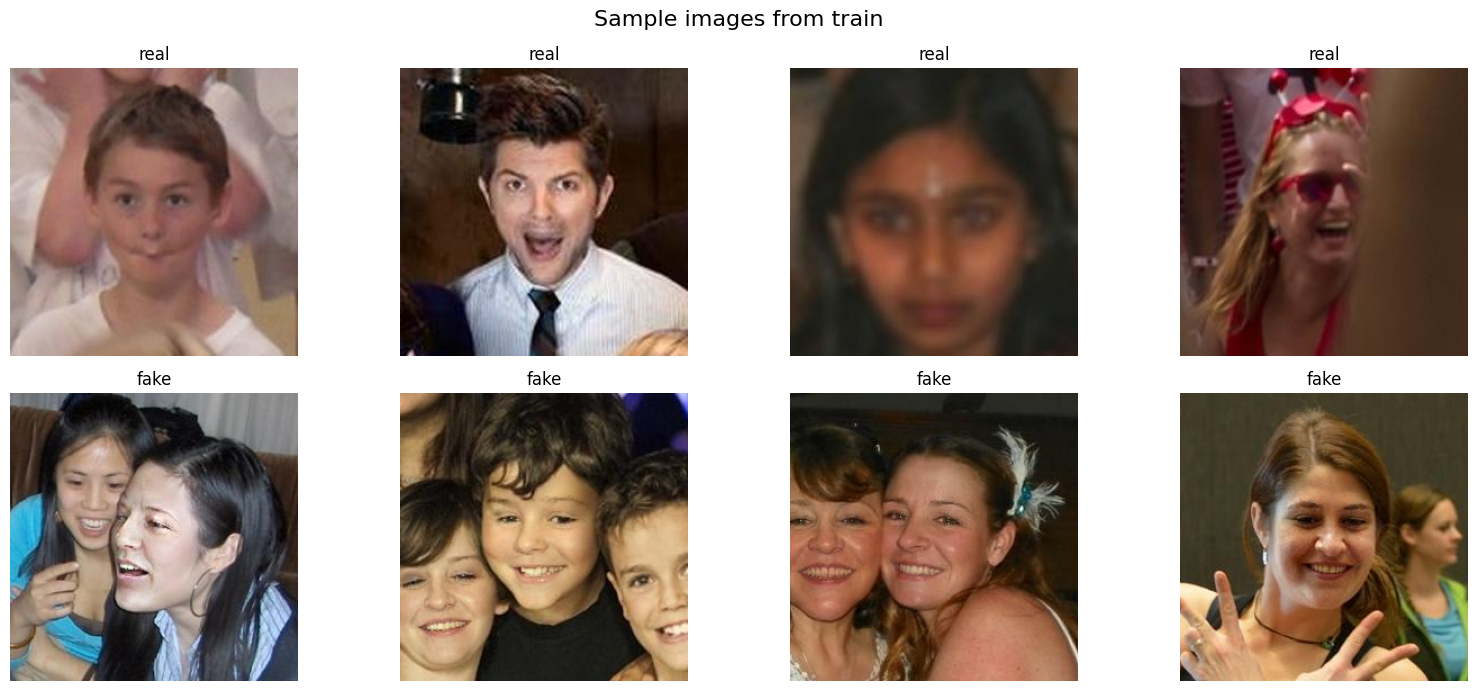

In [5]:
def load_image_safely(path: str):
    try:
        with Image.open(path) as image:
            return image.convert("RGB")
    except (OSError, UnidentifiedImageError) as error:
        print(f"Corrupted or unreadable image skipped: {path} | {error}")
        return None


def show_samples(dataframe: pd.DataFrame, split: str = "train", samples_per_class: int = 4) -> None:
    fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(4 * samples_per_class, 7))
    fig.suptitle(f"Sample images from {split}", fontsize=16)

    for row_idx, class_name in enumerate(CLASSES):
        subset = dataframe[(dataframe["split"] == split) & (dataframe["label"] == class_name)]
        samples = subset.sample(min(samples_per_class, len(subset)), random_state=42)
        print(f"Displaying {len(samples)} samples for {split}/{class_name}")

        for col_idx in range(samples_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            ax.set_title(class_name)
            if col_idx >= len(samples):
                continue

            path = samples.iloc[col_idx]["path"]
            image = load_image_safely(path)
            if image is not None:
                ax.imshow(image)
                ax.set_xlabel(Path(path).name[:32])

    plt.tight_layout()
    plt.show()


show_samples(df, split="train", samples_per_class=4)